# Over-Smoothing Visualization for CV-IPCW-HAL

This notebook demonstrates the **over-smoothing process** for IPCW estimators.

## Overview

Over-smoothing is a technique to enhance the robustness of HAL density estimators by deliberately choosing smaller `norm_constraint` values than the CV-optimal value:

1. **Step 1**: Use conservative cross-validation to find the optimal `norm_constraint` (λ*)
2. **Step 2**: Deliberately choose smaller λ values (e.g., 0.5×λ* to 1.0×λ*)
3. **Result**: Smaller λ → stricter constraint → fewer knot points → smaller working model

## Why Over-Smooth?

- **Smaller working models** are more robust and stable
- **Reduced variance** in density estimates
- **Better for EM refinement** - simpler initial models can be enhanced by EM iterations
- **Computational efficiency** - fewer knots means faster subsequent fitting

## Notebook Outline

1. **Data Simulation** — Generate right-censored data
2. **Conservative CV Tuning** — Find optimal `norm_constraint`
3. **Over-Smoothing Exploration** — Vary λ from 0.5× to 1.0× optimal
4. **Visualization** — Plot working model size vs. smoothing factor

In [1]:
# Imports
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from haldensity.utils import TruncatedGMM
from haldensity.censoring import (
    # Utilities
    KaplanMeier,
    compute_ipcw_weights,
    # Estimators
    RightCensoredIPCWEstimator,
    # Tuners
    RightCensoredOptunaHyperparameterTuner,
    # Metrics
    kl_divergence,
    incomplete_loglik,
)

print("✓ Imports successful")

✓ Imports successful


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Simulation

Generate right-censored data from a **truncated Gaussian Mixture Model** on [0,1]:
- True event times: `X ~ TruncatedGMM` (3 components)
- Censoring times: `C ~ Uniform(0, 1)`
- Observed: `T = min(X, C)` and `Δ = I(X ≤ C)`

In [2]:
# Simulation parameters
np.random.seed(1542)
rng = np.random.default_rng(42)

n_samples = 1000

# Use the DGP class - Truncated GMM with 3 components
sampler = TruncatedGMM(
    components=[
        {"mean": 0.2, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.5, "std": 0.05, "lower": 0, "upper": 1},
        {"mean": 0.8, "std": 0.05, "lower": 0, "upper": 1}
    ],
    weights=[0.33, 0.34, 0.33]
)

# Generate truncated GMM event times
X_true = sampler.generate_samples(n_samples)

# Generate uniform censoring times
C = rng.uniform(0.0, 1.0, size=n_samples)

# Observed data
T = np.minimum(X_true, C)
Delta = (X_true <= C).astype(int)

# Store in DataFrame
data = pd.DataFrame({"T": T, "Delta": Delta})

# Define true_pdf_fn for evaluation
true_pdf_fn = sampler.compute_density

print(f"Sample size: {n_samples}")
print(f"Censoring rate: {(1 - Delta.mean()):.1%}")
print(f"Observed events: {Delta.sum()}")
print(f"Censored observations: {(1 - Delta).sum()}")

Sample size: 1000
Censoring rate: 50.2%
Observed events: 498
Censored observations: 502


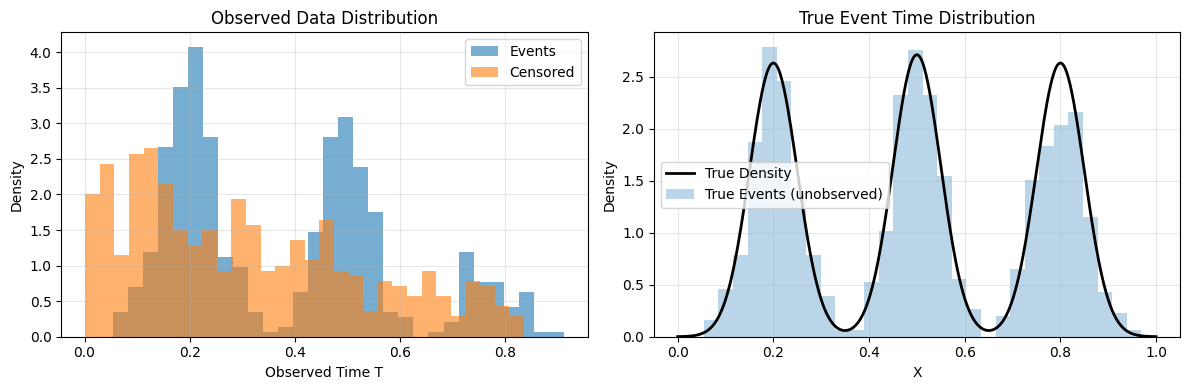

In [3]:
# Visualize data
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Observed data histogram
axes[0].hist(data.loc[data['Delta'] == 1, 'T'], bins=30, alpha=0.6, label='Events', density=True)
axes[0].hist(data.loc[data['Delta'] == 0, 'T'], bins=30, alpha=0.6, label='Censored', density=True)
axes[0].set_xlabel('Observed Time T')
axes[0].set_ylabel('Density')
axes[0].set_title('Observed Data Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# True density
grid = np.linspace(0, 1, 500)
true_density = sampler.compute_density(grid)
axes[1].plot(grid, true_density, 'k-', linewidth=2, label='True Density')
axes[1].hist(X_true, bins=30, alpha=0.3, density=True, label='True Events (unobserved)')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Density')
axes[1].set_title('True Event Time Distribution')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Conservative CV Tuning

First, we use the conservative cross-validation strategy to find the optimal `norm_constraint` (λ*).

The conservative adjustment automatically selects a smaller `norm_constraint` that is within a tolerance of the CV-optimal value.

In [4]:
# Create tuner with conservative adjustment (default: enabled)
tuner = RightCensoredOptunaHyperparameterTuner(
    estimator_name="RightCensoredIPCWEstimator",
    data=data,
    cv_folds=5,
    random_state=42,
    n_grid_points=200,
    param_overrides={
        "norm_constraint": {"low": 0.1, "high": 500.0, "log": True},
        "basis_order": [0],  # Fix basis_order to 0 for this example
    },
    # Conservative adjustment is enabled by default
    use_conservative_adjustment=True,
    conservative_k_percent=0.05,  # 5% of SD
    silent=False,
)

print("Starting CV optimization with conservative adjustment...")
start_time = time.time()
result = tuner.optimize(n_trials=15)
total_time = time.time() - start_time

print(f"\n{'='*60}")
print(f"Optimization Complete")
print(f"{'='*60}")
print(f"Total time: {total_time:.2f}s")

Starting CV optimization with conservative adjustment...


Optuna CV:  20%|██        | 3/15 [00:03<00:13,  1.15s/trial, LL=-1.64, best=-1.64, order=0]  /Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
Optuna CV: 100%|██████████| 15/15 [00:15<00:00,  1.06s/trial, LL=-1.64, best=-1.63, order=0] 



Conservative 5% SD Adjustment
Optuna best norm_constraint: 16.3840
CV LL at Optuna best: -1.6290 (SD: 4.4604)
Threshold: -1.6290 - 0.05*4.4604 = -1.8520

Searching smaller norm_constraints (step_size=0.3277)...
  Step 12: NC=12.4518, CV_LL=-1.9375 < threshold
  Stopping search.

Conservative Selection Complete
Optuna NC:       16.3840
Conservative NC: 12.7795
Reduction:       3.6045 (22.0%)

Optimization Complete
Total time: 30.71s


In [5]:
# Extract optimal norm_constraint from conservative tuning
optuna_params = result.get("optuna_params", result.get("best_params", {}))
conservative_params = result.get("conservative_params", result.get("best_params", {}))

optuna_nc = optuna_params.get("norm_constraint", None)
conservative_nc = conservative_params.get("norm_constraint", None)

print(f"{'='*60}")
print(f"Conservative Tuning Results")
print(f"{'='*60}")
print(f"Optuna best norm_constraint:       {optuna_nc:.4f}")
print(f"Conservative norm_constraint (λ*): {conservative_nc:.4f}")
if optuna_nc and conservative_nc:
    reduction = (optuna_nc - conservative_nc) / optuna_nc * 100
    print(f"Reduction:                         {reduction:.1f}%")
print(f"{'='*60}")

Conservative Tuning Results
Optuna best norm_constraint:       16.3840
Conservative norm_constraint (λ*): 12.7795
Reduction:                         22.0%


## 3. Over-Smoothing Exploration

Now we explore how the **working model size** (number of knots) changes as we vary the smoothing factor.

We will test `norm_constraint` values from **0.5×λ*** to **1.0×λ*** and observe:
- How many knot points are selected
- How the density estimate changes
- Trade-offs between model complexity and fit quality

In [6]:
# Define smoothing factors to explore
smoothing_factors = np.linspace(0.5, 1.0, 11)  # 0.5, 0.55, 0.6, ..., 1.0
optimal_nc = conservative_nc  # Use conservative NC as the baseline

print(f"{'='*60}")
print(f"Over-Smoothing Exploration")
print(f"{'='*60}")
print(f"Optimal norm_constraint (λ*): {optimal_nc:.4f}")
print(f"Smoothing factors to test: {smoothing_factors}")
print(f"{'='*60}\n")

# Prepare IPCW data (fit Kaplan-Meier first)
km = KaplanMeier()
km.fit(data, time_col="T", delta_col="Delta")

T_vals = np.asarray(data["T"].values, dtype=float)
Delta_vals = np.asarray(data["Delta"].values, dtype=int)

def S_c_predict(t):
    """Predict censoring survival."""
    return np.atleast_1d(km.predict(t))

ipcw_weights = compute_ipcw_weights(T=T_vals, Delta=Delta_vals, S_c_predict=S_c_predict)

# Filter to uncensored observations
uncensored_mask = Delta_vals == 1
ipcw_data = pd.DataFrame({"W1": T_vals[uncensored_mask]})
ipcw_weights_unc = ipcw_weights[uncensored_mask]

print(f"Uncensored observations: {uncensored_mask.sum()}")
print(f"IPCW weights: min={ipcw_weights_unc.min():.4f}, max={ipcw_weights_unc.max():.4f}")

Over-Smoothing Exploration
Optimal norm_constraint (λ*): 12.7795
Smoothing factors to test: [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]

Uncensored observations: 498
IPCW weights: min=1.0638, max=9.5098


In [7]:
# Fit models at different smoothing levels and record results
results_list = []
eval_grid = np.linspace(0, 1, 500)

print("Fitting models at different smoothing levels...\n")

for factor in smoothing_factors:
    nc = optimal_nc * factor
    
    # Fit IPCW estimator
    estimator = RightCensoredIPCWEstimator(
        norm_constraint=nc,
        basis_order=0,
        solver="ECOS",
    )
    estimator.fit(ipcw_data, sample_weights=ipcw_weights_unc)
    
    # Get results
    est_results = estimator.get_results()
    n_knots = len(est_results['grid_points_hal_selected'])
    
    # Evaluate
    est_density = estimator.get_density_at_points(eval_grid)
    ll = incomplete_loglik(estimator, data, time_col="T", delta_col="Delta")
    kl = kl_divergence(
        true_pdf_fn=true_pdf_fn,
        grid=eval_grid,
        est_density=est_density,
    )
    
    results_list.append({
        'factor': factor,
        'norm_constraint': nc,
        'n_knots': n_knots,
        'log_likelihood': ll,
        'kl_divergence': kl,
        'estimator': estimator,
        'density': est_density,
    })
    
    print(f"Factor={factor:.2f} | NC={nc:8.4f} | Knots={n_knots:3d} | LL={ll:8.4f} | KL={kl:.6f}")

print("\n✓ All models fitted successfully")

Fitting models at different smoothing levels...

Factor=0.50 | NC=  6.3898 | Knots= 18 | LL=-40.0419 | KL=0.178303
Factor=0.55 | NC=  7.0287 | Knots= 22 | LL=-30.2158 | KL=0.161840
Factor=0.60 | NC=  7.6677 | Knots= 24 | LL=-21.5062 | KL=0.147080
Factor=0.65 | NC=  8.3067 | Knots= 25 | LL=-13.7701 | KL=0.134166
Factor=0.70 | NC=  8.9457 | Knots= 25 | LL= -6.9455 | KL=0.122984
Factor=0.75 | NC=  9.5846 | Knots= 28 | LL= -1.5443 | KL=0.114817
Factor=0.80 | NC= 10.2236 | Knots= 29 | LL=  2.0173 | KL=0.110749
Factor=0.85 | NC= 10.8626 | Knots= 31 | LL=  5.6173 | KL=0.106674
Factor=0.90 | NC= 11.5016 | Knots= 32 | LL=  8.7846 | KL=0.104036
Factor=0.95 | NC= 12.1405 | Knots= 33 | LL= 11.6876 | KL=0.102050
Factor=1.00 | NC= 12.7795 | Knots= 33 | LL= 14.4053 | KL=0.100601

✓ All models fitted successfully


## 4. Visualization

### 4.1 Working Model Size vs. Smoothing Factor

This plot shows how the number of knot points (working model size) changes as we increase the over-smoothing factor.

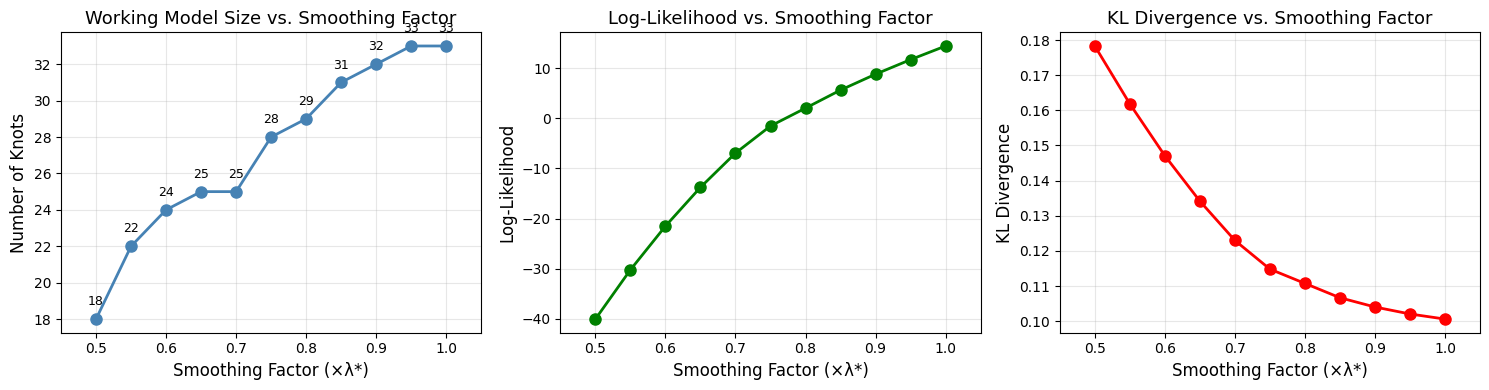

In [8]:
# Create results DataFrame
results_df = pd.DataFrame(results_list)

# Plot: Working Model Size vs. Smoothing Factor
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Number of knots vs. smoothing factor
ax1 = axes[0]
ax1.plot(results_df['factor'], results_df['n_knots'], 'o-', linewidth=2, markersize=8, color='steelblue')
ax1.set_xlabel('Smoothing Factor (×λ*)', fontsize=12)
ax1.set_ylabel('Number of Knots', fontsize=12)
ax1.set_title('Working Model Size vs. Smoothing Factor', fontsize=13)
ax1.grid(alpha=0.3)
ax1.set_xlim(0.45, 1.05)

# Add annotations
for i, row in results_df.iterrows():
    ax1.annotate(f"{row['n_knots']}", 
                 (row['factor'], row['n_knots']), 
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', fontsize=9)

# Plot 2: Log-likelihood vs. smoothing factor
ax2 = axes[1]
ax2.plot(results_df['factor'], results_df['log_likelihood'], 'o-', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('Smoothing Factor (×λ*)', fontsize=12)
ax2.set_ylabel('Log-Likelihood', fontsize=12)
ax2.set_title('Log-Likelihood vs. Smoothing Factor', fontsize=13)
ax2.grid(alpha=0.3)
ax2.set_xlim(0.45, 1.05)

# Plot 3: KL divergence vs. smoothing factor
ax3 = axes[2]
ax3.plot(results_df['factor'], results_df['kl_divergence'], 'o-', linewidth=2, markersize=8, color='red')
ax3.set_xlabel('Smoothing Factor (×λ*)', fontsize=12)
ax3.set_ylabel('KL Divergence', fontsize=12)
ax3.set_title('KL Divergence vs. Smoothing Factor', fontsize=13)
ax3.grid(alpha=0.3)
ax3.set_xlim(0.45, 1.05)

plt.tight_layout()
plt.show()

### 4.2 Density Estimates at Different Smoothing Levels

This plot shows how the estimated density changes as we vary the smoothing factor.

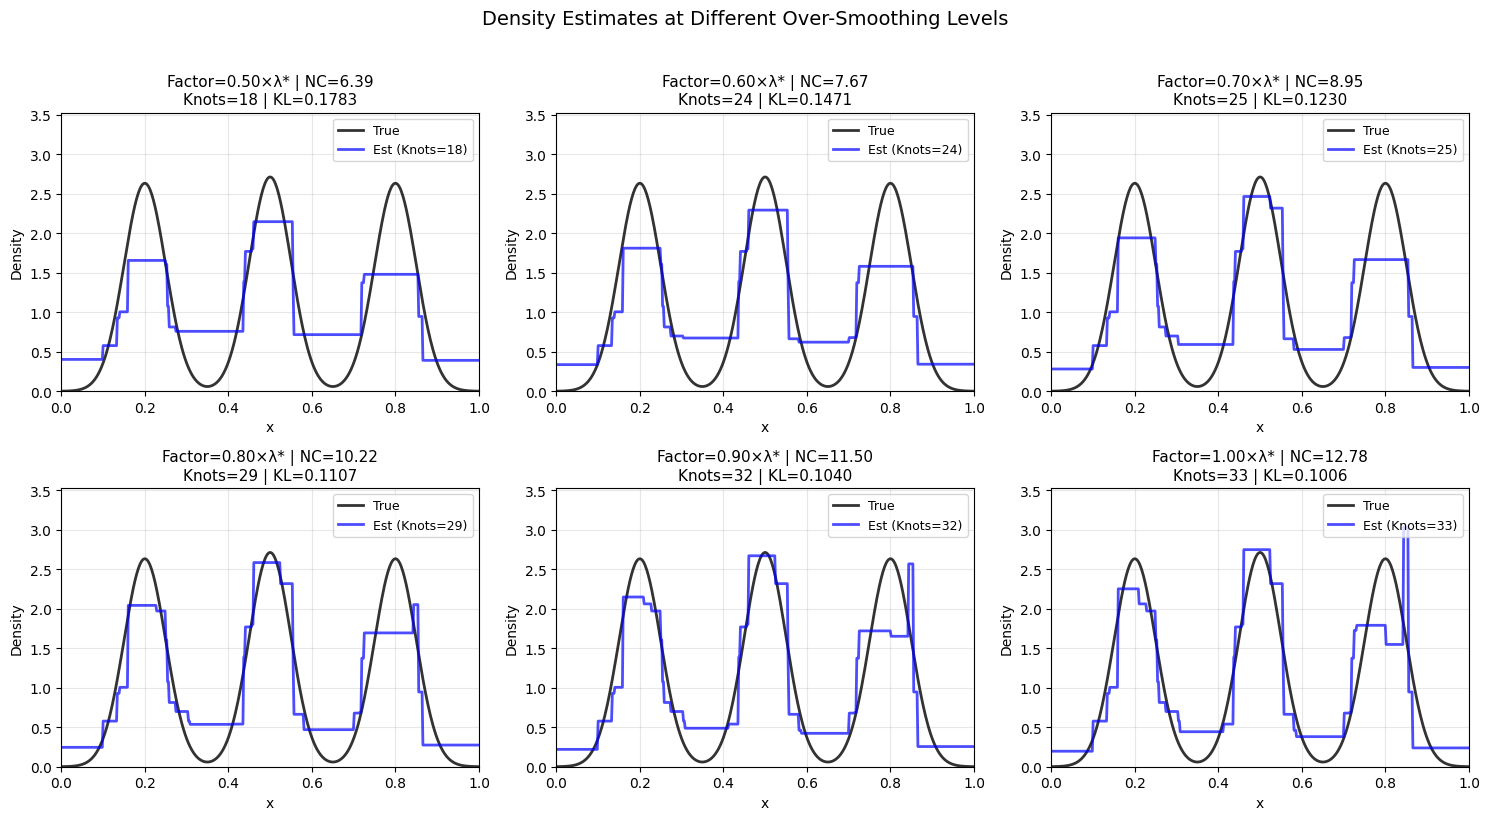

In [9]:
# Plot density estimates at different smoothing levels
# Select a subset of factors to display
display_factors = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
display_results = results_df[results_df['factor'].isin(display_factors)]

# Make grid adaptive based on number of results to display
n_display = len(display_results)
n_cols = min(3, n_display)  # Max 3 columns
n_rows = (n_display + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

# Handle single plot case and flatten
if n_display == 1:
    axes = np.array([axes])
else:
    axes = np.atleast_1d(axes).flatten()

for idx, (_, row) in enumerate(display_results.iterrows()):
    if idx >= len(axes):
        break  # Safety check
    ax = axes[idx]
    
    # True density
    ax.plot(eval_grid, true_density, 'k-', linewidth=2, label='True', alpha=0.8)
    
    # Estimated density
    ax.plot(eval_grid, row['density'], 'b-', linewidth=2, 
            label=f'Est (Knots={row["n_knots"]})', alpha=0.7)
    
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'Factor={row["factor"]:.2f}×λ* | NC={row["norm_constraint"]:.2f}\nKnots={row["n_knots"]} | KL={row["kl_divergence"]:.4f}', 
                fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(true_density) * 1.3)

# Hide any unused subplots
for idx in range(n_display, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Density Estimates at Different Over-Smoothing Levels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Summary Table

A comprehensive summary of the over-smoothing exploration results.

In [10]:
# Create summary table
summary_df = results_df[['factor', 'norm_constraint', 'n_knots', 'log_likelihood', 'kl_divergence']].copy()
summary_df.columns = ['Factor (×λ*)', 'Norm Constraint', 'N Knots', 'Log-Likelihood', 'KL Divergence']

# Round for display
summary_df['Factor (×λ*)'] = summary_df['Factor (×λ*)'].round(2)
summary_df['Norm Constraint'] = summary_df['Norm Constraint'].round(4)
summary_df['Log-Likelihood'] = summary_df['Log-Likelihood'].round(4)
summary_df['KL Divergence'] = summary_df['KL Divergence'].round(6)

print("="*80)
print("OVER-SMOOTHING SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

# Calculate key statistics
baseline_knots = summary_df.loc[summary_df['Factor (×λ*)'] == 1.0, 'N Knots'].values[0]
min_knots = summary_df['N Knots'].min()
max_knots = summary_df['N Knots'].max()

print(f"\nKey Observations:")
print(f"  • At factor=1.0 (no over-smoothing): {baseline_knots} knots")
print(f"  • At factor=0.5 (max over-smoothing): {summary_df.loc[summary_df['Factor (×λ*)'] == 0.5, 'N Knots'].values[0]} knots")
print(f"  • Knot range: {min_knots} to {max_knots}")
print(f"  • Reduction potential: {(baseline_knots - min_knots) / baseline_knots * 100:.1f}%")

OVER-SMOOTHING SUMMARY
 Factor (×λ*)  Norm Constraint  N Knots  Log-Likelihood  KL Divergence
         0.50           6.3898       18        -40.0419       0.178303
         0.55           7.0287       22        -30.2158       0.161840
         0.60           7.6677       24        -21.5062       0.147080
         0.65           8.3067       25        -13.7701       0.134166
         0.70           8.9457       25         -6.9455       0.122984
         0.75           9.5846       28         -1.5443       0.114817
         0.80          10.2236       29          2.0173       0.110749
         0.85          10.8626       31          5.6173       0.106674
         0.90          11.5016       32          8.7846       0.104036
         0.95          12.1405       33         11.6876       0.102050
         1.00          12.7795       33         14.4053       0.100601

Key Observations:
  • At factor=1.0 (no over-smoothing): 33 knots
  • At factor=0.5 (max over-smoothing): 18 knots
  • Knot 

### 4.4 Combined Visualization: Model Size vs. Quality Trade-off

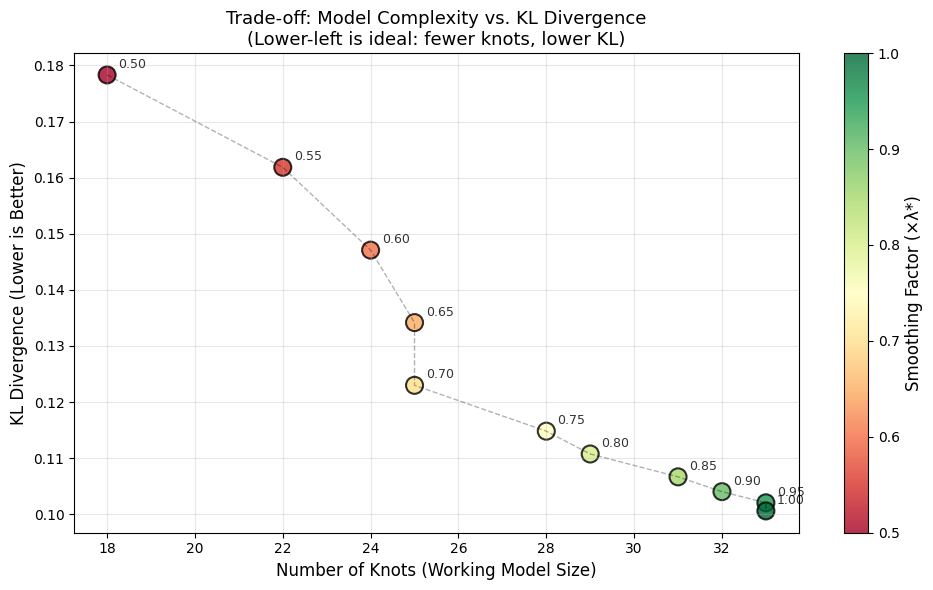

In [11]:
# Combined visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot knots vs. KL divergence with factor as color
scatter = ax.scatter(
    results_df['n_knots'], 
    results_df['kl_divergence'],
    c=results_df['factor'],
    cmap='RdYlGn',  # Red for low factor, Green for high factor
    s=150,
    edgecolors='black',
    linewidths=1.5,
    alpha=0.8
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Smoothing Factor (×λ*)', fontsize=12)

# Connect points with a line
ax.plot(results_df['n_knots'], results_df['kl_divergence'], 'k--', alpha=0.3, linewidth=1)

# Add annotations
for _, row in results_df.iterrows():
    ax.annotate(f"{row['factor']:.2f}", 
                (row['n_knots'], row['kl_divergence']),
                textcoords="offset points",
                xytext=(8, 5),
                fontsize=9,
                alpha=0.8)

ax.set_xlabel('Number of Knots (Working Model Size)', fontsize=12)
ax.set_ylabel('KL Divergence (Lower is Better)', fontsize=12)
ax.set_title('Trade-off: Model Complexity vs. KL Divergence\n(Lower-left is ideal: fewer knots, lower KL)', fontsize=13)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## 5. Forward Grid Search for Over-Smoothed Candidates

### Key Insight: Non-Monotonic Relationship

From the exploration above, we observe that **smaller λ does NOT always yield fewer knots**. This is because:

1. L1 regularization affects which coefficients get pushed toward zero
2. The sparsity pattern depends on the data and the specific λ value
3. Sometimes a slightly larger λ can eliminate more basis functions

### Forward Grid Search Strategy

The goal is to find over-smoothed IPCW models that:
1. Have **fewer knots** than the baseline (factor=1.0)
2. Still maintain reasonable fit quality
3. Will serve as good initial models for EM refinement

**Algorithm:**
1. Compute the **baseline** model at factor=1.0 → get `baseline_knots`
2. Search over a fine grid of factors (e.g., 0.3 to 1.0)
3. **Filter**: Keep only models with `n_knots < baseline_knots`
4. **Rank** by knot count (smaller is better), then by factor (higher is better)
5. **Select** top candidates for EM refinement

### Handling Edge Cases: No Smaller Models Found

Sometimes the baseline already has the **minimum number of knots**. In this case, we use fallback strategies:

| Fallback | Description | When to Use |
|----------|-------------|-------------|
| **A: Equal-knot models** | Use models with same knot count but smaller λ (more regularization) | When baseline isn't unique |
| **B: Expand search** | Try smaller factors (0.1, 0.2, 0.3) to find smaller models | When search range is too narrow |
| **C: Use baseline** | Just use baseline as initial model for EM | When baseline is truly optimal |

**Rationale for Fallback A**: Even if the knot count is the same, models with smaller λ have:
- Stronger L1 regularization on coefficients
- More shrinkage toward zero
- May still benefit from EM coefficient refinement

In [12]:
# Forward Grid Search Implementation

# Convert results to DataFrame for easier manipulation
results_df = pd.DataFrame(results_list)

# Get baseline (factor=1.0) knot count
baseline_row = results_df[results_df['factor'] == 1.0].iloc[0]
baseline_knots = baseline_row['n_knots']
baseline_ll = baseline_row['log_likelihood']
baseline_kl = baseline_row['kl_divergence']

print("=" * 70)
print("FORWARD GRID SEARCH FOR OVER-SMOOTHED CANDIDATES")
print("=" * 70)
print(f"\nBaseline (factor=1.0): {baseline_knots} knots, LL={baseline_ll:.4f}, KL={baseline_kl:.6f}")

# Filter for models with FEWER knots than baseline
smaller_models = results_df[results_df['n_knots'] < baseline_knots].copy()

print(f"\n{'─' * 70}")
print("Models with FEWER knots than baseline:")
print(f"{'─' * 70}")

if len(smaller_models) == 0:
    print("\n⚠ NO MODELS FOUND WITH FEWER KNOTS THAN BASELINE!")
    print("─" * 70)
    print("""
This can happen due to the non-monotonic relationship between λ and knot count.
The baseline already has the minimum working model size in the search range.

FALLBACK STRATEGIES:
""")
    
    # Strategy 1: Check if we can expand the search range
    min_factor_tested = results_df['factor'].min()
    print(f"  1. EXPAND SEARCH RANGE")
    print(f"     Current minimum factor: {min_factor_tested:.2f}")
    print(f"     Try smaller factors: 0.1, 0.2, 0.3, etc.")
    
    # Strategy 2: Use models with equal knot counts but different regularization
    equal_models = results_df[results_df['n_knots'] == baseline_knots].copy()
    equal_models = equal_models[equal_models['factor'] < 1.0]
    if len(equal_models) > 0:
        print(f"\n  2. USE MODELS WITH EQUAL KNOTS BUT MORE REGULARIZATION")
        print(f"     Found {len(equal_models)} models with {baseline_knots} knots:")
        for _, row in equal_models.iterrows():
            print(f"       factor={row['factor']:.2f}, LL={row['log_likelihood']:.4f}")
        print("     → More regularization may help EM even with same knot count")
    
    # Strategy 3: Just use the baseline
    print(f"\n  3. USE BASELINE DIRECTLY")
    print(f"     The baseline (factor=1.0) is already optimal for this data")
    print(f"     → Proceed with EM using baseline as initial model")
    
    # For this case, we'll use equal-knot models + baseline
    smaller_models = equal_models  # Will be used in next cell
    
else:
    # Sort by n_knots (ascending), then by factor (descending - prefer less smoothing)
    smaller_models = smaller_models.sort_values(
        by=['n_knots', 'factor'], 
        ascending=[True, False]
    ).reset_index(drop=True)
    
    print(f"\n{'Rank':<6} {'Factor':<8} {'Knots':<8} {'LL':<12} {'KL':<12} {'Knot Reduction':<15}")
    print("-" * 70)
    
    for i, row in smaller_models.iterrows():
        knot_reduction = baseline_knots - row['n_knots']
        knot_pct = knot_reduction / baseline_knots * 100
        print(f"{i+1:<6} {row['factor']:<8.2f} {row['n_knots']:<8} {row['log_likelihood']:<12.4f} "
              f"{row['kl_divergence']:<12.6f} -{knot_reduction} ({knot_pct:.1f}%)")

print(f"\n{'─' * 70}")
print("SELECTION CRITERIA:")
print(f"{'─' * 70}")
print("""
For over-smoothed initial models for EM, we recommend selecting candidates that:

1. Have SMALLER working model size (fewer knots)
   → Simpler model, more robust to overfitting
   → EM can refine the coefficients without changing the model structure

2. Maintain reasonable fit quality
   → Not too far below the baseline log-likelihood
   → KL divergence within acceptable range

3. When multiple candidates have similar knot counts:
   → Prefer HIGHER factor (closer to CV-optimal)
   → These tend to have better initial fit quality

4. If NO smaller models exist:
   → Use models with equal knots but more regularization (smaller factor)
   → Or expand the search range to try smaller factors
   → Or just use the baseline directly
""")
print("=" * 70)

FORWARD GRID SEARCH FOR OVER-SMOOTHED CANDIDATES

Baseline (factor=1.0): 33 knots, LL=14.4053, KL=0.100601

──────────────────────────────────────────────────────────────────────
Models with FEWER knots than baseline:
──────────────────────────────────────────────────────────────────────

Rank   Factor   Knots    LL           KL           Knot Reduction 
----------------------------------------------------------------------
1      0.50     18       -40.0419     0.178303     -15 (45.5%)
2      0.55     22       -30.2158     0.161840     -11 (33.3%)
3      0.60     24       -21.5062     0.147080     -9 (27.3%)
4      0.70     25       -6.9455      0.122984     -8 (24.2%)
5      0.65     25       -13.7701     0.134166     -8 (24.2%)
6      0.75     28       -1.5443      0.114817     -5 (15.2%)
7      0.80     29       2.0173       0.110749     -4 (12.1%)
8      0.85     31       5.6173       0.106674     -2 (6.1%)
9      0.90     32       8.7846       0.104036     -1 (3.0%)

─────────────

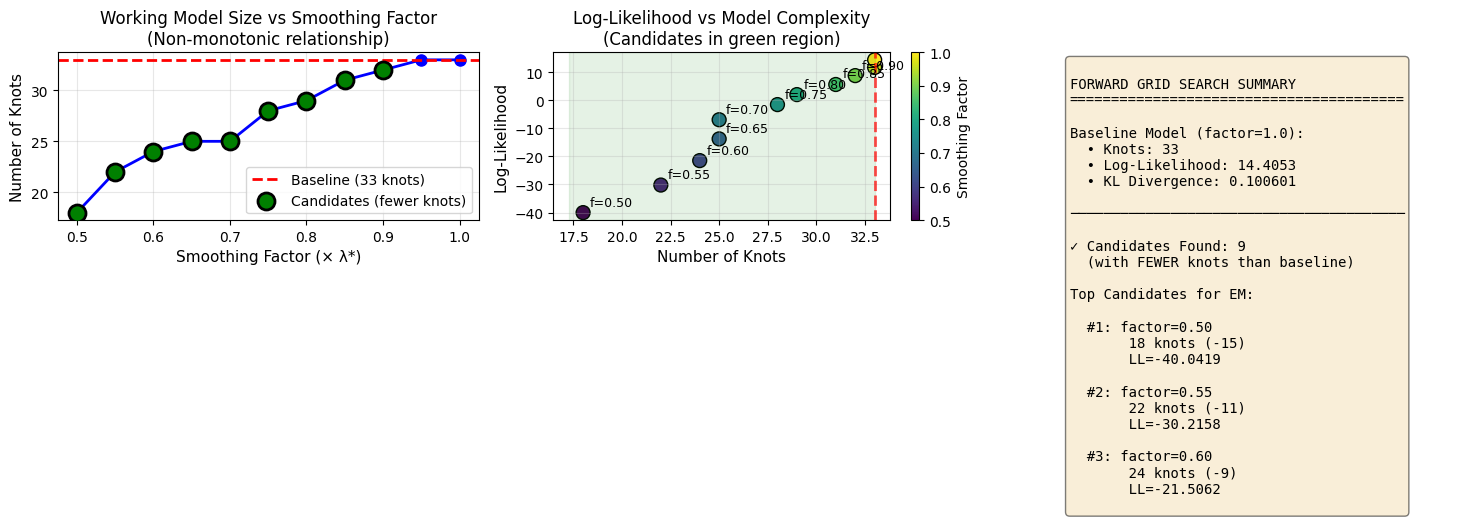

In [13]:
# Visualize the Forward Grid Search Results

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Recalculate strictly smaller models for visualization
strictly_smaller = results_df[results_df['n_knots'] < baseline_knots]
equal_knot_models = results_df[(results_df['n_knots'] == baseline_knots) & (results_df['factor'] < 1.0)]

# Plot 1: Knots vs Factor (showing non-monotonicity)
ax1 = axes[0]
ax1.plot(results_df['factor'], results_df['n_knots'], 'b-o', linewidth=2, markersize=8)
ax1.axhline(y=baseline_knots, color='r', linestyle='--', linewidth=2, label=f'Baseline ({baseline_knots} knots)')

# Highlight candidates
if len(strictly_smaller) > 0:
    ax1.scatter(strictly_smaller['factor'], strictly_smaller['n_knots'], 
                c='green', s=150, zorder=5, edgecolors='black', linewidths=2,
                label='Candidates (fewer knots)')
elif len(equal_knot_models) > 0:
    ax1.scatter(equal_knot_models['factor'], equal_knot_models['n_knots'], 
                c='orange', s=150, zorder=5, edgecolors='black', linewidths=2,
                label='Fallback (equal knots, more reg.)')

ax1.set_xlabel('Smoothing Factor (× λ*)', fontsize=11)
ax1.set_ylabel('Number of Knots', fontsize=11)
ax1.set_title('Working Model Size vs Smoothing Factor\n(Non-monotonic relationship)', fontsize=12)
ax1.legend(loc='best')
ax1.grid(alpha=0.3)

# Plot 2: Log-Likelihood vs Knots (trade-off)
ax2 = axes[1]
scatter = ax2.scatter(results_df['n_knots'], results_df['log_likelihood'], 
                      c=results_df['factor'], cmap='viridis', s=100, edgecolors='black')
ax2.axvline(x=baseline_knots, color='r', linestyle='--', linewidth=2, alpha=0.7)

# Label the candidates
if len(strictly_smaller) > 0:
    for _, row in strictly_smaller.iterrows():
        ax2.annotate(f"f={row['factor']:.2f}", 
                     (row['n_knots'], row['log_likelihood']),
                     xytext=(5, 5), textcoords='offset points', fontsize=9)
    # Shade the "candidate zone" (fewer knots than baseline)
    ax2.axvspan(ax2.get_xlim()[0], baseline_knots, alpha=0.1, color='green')

ax2.set_xlabel('Number of Knots', fontsize=11)
ax2.set_ylabel('Log-Likelihood', fontsize=11)
title_suffix = "(Candidates in green region)" if len(strictly_smaller) > 0 else "(Baseline is minimum)"
ax2.set_title(f'Log-Likelihood vs Model Complexity\n{title_suffix}', fontsize=12)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('Smoothing Factor')
ax2.grid(alpha=0.3)

# Plot 3: Selection Summary
ax3 = axes[2]
ax3.axis('off')

# Create summary text
summary_text = f"""
FORWARD GRID SEARCH SUMMARY
{'='*40}

Baseline Model (factor=1.0):
  • Knots: {baseline_knots}
  • Log-Likelihood: {baseline_ll:.4f}
  • KL Divergence: {baseline_kl:.6f}

{'─'*40}
"""

if len(strictly_smaller) > 0:
    summary_text += f"""
✓ Candidates Found: {len(strictly_smaller)}
  (with FEWER knots than baseline)

Top Candidates for EM:
"""
    for i, row in strictly_smaller.head(3).iterrows():
        reduction = baseline_knots - row['n_knots']
        summary_text += f"""
  #{i+1}: factor={row['factor']:.2f}
       {row['n_knots']} knots (-{reduction})
       LL={row['log_likelihood']:.4f}
"""
elif len(equal_knot_models) > 0:
    summary_text += f"""
⚠ No models with fewer knots found.

FALLBACK: Using models with equal
knots but more regularization:
  • {len(equal_knot_models)} models available
  • Same {baseline_knots} knots
  • Stronger L1 regularization

Top Fallback Models:
"""
    for i, (_, row) in enumerate(equal_knot_models.head(3).iterrows()):
        summary_text += f"""
  #{i+1}: factor={row['factor']:.2f}
       LL={row['log_likelihood']:.4f}
"""
else:
    summary_text += """
⚠ Baseline is already optimal.

FALLBACK: Using baseline directly.
  • No smaller models available
  • Baseline has minimum knots
  
EM will refine coefficients
without reducing model size.
"""

ax3.text(0.05, 0.95, summary_text, transform=ax3.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [14]:
# Select candidates for EM refinement based on forward grid search

print("=" * 60)
print("SELECTING CANDIDATES FOR EM REFINEMENT")
print("=" * 60)

# Check if we found any models with strictly fewer knots
strictly_smaller = results_df[results_df['n_knots'] < baseline_knots]

if len(strictly_smaller) > 0:
    # CASE 1: We found models with fewer knots - use those
    print("\n✓ Found models with FEWER knots than baseline")
    
    unique_knot_counts = sorted(strictly_smaller['n_knots'].unique())
    
    # For each unique knot count, pick the one with highest factor
    selected_candidates = []
    for n_knots in unique_knot_counts:
        candidates_with_n = strictly_smaller[strictly_smaller['n_knots'] == n_knots]
        best = candidates_with_n.loc[candidates_with_n['factor'].idxmax()]
        selected_candidates.append(best['factor'])
    
    # Add baseline for comparison
    selected_candidates.append(1.0)
    em_factors_to_test = sorted(list(set(selected_candidates)))
    
else:
    # CASE 2: No models with fewer knots - fallback strategies
    print("\n⚠ No models with FEWER knots than baseline")
    print("  Using FALLBACK STRATEGY...")
    
    # Check for models with EQUAL knots but more regularization
    equal_knot_models = results_df[
        (results_df['n_knots'] == baseline_knots) & 
        (results_df['factor'] < 1.0)
    ]
    
    if len(equal_knot_models) > 0:
        # FALLBACK A: Use equal-knot models with more regularization
        print(f"\n  Strategy: Use models with EQUAL knots ({baseline_knots}) but more regularization")
        print("  Rationale: Stronger regularization may still help EM refinement")
        
        # Select a few representative factors
        selected_candidates = list(equal_knot_models['factor'].values)
        selected_candidates.append(1.0)
        em_factors_to_test = sorted(list(set(selected_candidates)))
        
    else:
        # FALLBACK B: The baseline is unique - just use baseline and a few lower factors
        print(f"\n  Strategy: Use baseline + lower factors for comparison")
        print("  Rationale: Even without knot reduction, EM can refine coefficients")
        
        # Use baseline and a few representative lower factors
        all_factors = sorted(results_df['factor'].unique())
        # Pick evenly spaced factors including baseline
        if len(all_factors) > 5:
            indices = np.linspace(0, len(all_factors)-1, 5, dtype=int)
            em_factors_to_test = [all_factors[i] for i in indices]
        else:
            em_factors_to_test = all_factors
        
        # Ensure baseline is included
        if 1.0 not in em_factors_to_test:
            em_factors_to_test.append(1.0)
        em_factors_to_test = sorted(em_factors_to_test)

print(f"\n{'─' * 60}")
print(f"Factors selected for EM refinement: {em_factors_to_test}")
print(f"{'─' * 60}")
print(f"\nCorresponding model sizes:")
for f in em_factors_to_test:
    row = results_df[results_df['factor'] == f].iloc[0]
    if f == 1.0:
        marker = " ← BASELINE"
    elif row['n_knots'] < baseline_knots:
        marker = " ← SMALLER (preferred)"
    elif row['n_knots'] == baseline_knots:
        marker = " ← EQUAL (more regularized)"
    else:
        marker = ""
    print(f"  factor={f:.2f}: {row['n_knots']} knots, LL={row['log_likelihood']:.4f}{marker}")

print("\n" + "=" * 60)

SELECTING CANDIDATES FOR EM REFINEMENT

✓ Found models with FEWER knots than baseline

────────────────────────────────────────────────────────────
Factors selected for EM refinement: [np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.8500000000000001), np.float64(0.9), 1.0]
────────────────────────────────────────────────────────────

Corresponding model sizes:
  factor=0.50: 18 knots, LL=-40.0419 ← SMALLER (preferred)
  factor=0.55: 22 knots, LL=-30.2158 ← SMALLER (preferred)
  factor=0.60: 24 knots, LL=-21.5062 ← SMALLER (preferred)
  factor=0.70: 25 knots, LL=-6.9455 ← SMALLER (preferred)
  factor=0.75: 28 knots, LL=-1.5443 ← SMALLER (preferred)
  factor=0.80: 29 knots, LL=2.0173 ← SMALLER (preferred)
  factor=0.85: 31 knots, LL=5.6173 ← SMALLER (preferred)
  factor=0.90: 32 knots, LL=8.7846 ← SMALLER (preferred)
  factor=1.00: 33 knots, LL=14.4053 ← BASELINE



## 5. Key Takeaways

### What We Learned

1. **Over-smoothing reduces model complexity**: Decreasing the smoothing factor (using smaller λ) results in fewer knot points in the working model.

2. **Trade-off exists**: While over-smoothing reduces model size, it may also slightly increase bias (higher KL divergence). The optimal choice depends on downstream use.

3. **Sweet spot for EM**: For EM refinement, a moderately over-smoothed initial model (factor ~0.6-0.8) often provides a good balance between:
   - Enough flexibility to capture key density features
   - Sufficient simplicity for robust EM iterations

### Recommended Usage

| Use Case | Suggested Factor | Reasoning |
|----------|------------------|-----------|
| Quick baseline | 1.0 | No over-smoothing, use CV-optimal |
| EM refinement | 0.6-0.8 | Moderate complexity for EM to refine |
| Very robust estimate | 0.5 | Maximum over-smoothing, fewest knots |

### Next Steps

The over-smoothed IPCW model can be used as initialization for:
- `RightCensoredEMStage` - Standalone EM refinement
- `RightCensoredEMEstimator` - Bundled IPCW + EM workflow

By starting with a simpler working model, the EM algorithm can more effectively refine the density estimate.

In [15]:
# Final summary
print("="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"\nOptimal norm_constraint (λ*) from conservative CV: {optimal_nc:.4f}")
print(f"\nOver-smoothing exploration completed with {len(smoothing_factors)} factors")
print(f"Factors tested: {list(smoothing_factors.round(2))}")
print(f"\nModel size range:")
print(f"  - Minimum knots (factor=0.5): {results_df.loc[results_df['factor'] == 0.5, 'n_knots'].values[0]}")
print(f"  - Maximum knots (factor=1.0): {results_df.loc[results_df['factor'] == 1.0, 'n_knots'].values[0]}")
print(f"\nKL divergence range:")
print(f"  - Best KL: {results_df['kl_divergence'].min():.6f} at factor={results_df.loc[results_df['kl_divergence'].idxmin(), 'factor']:.2f}")
print(f"  - Worst KL: {results_df['kl_divergence'].max():.6f} at factor={results_df.loc[results_df['kl_divergence'].idxmax(), 'factor']:.2f}")
print("="*60)

FINAL SUMMARY

Optimal norm_constraint (λ*) from conservative CV: 12.7795

Over-smoothing exploration completed with 11 factors
Factors tested: [np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.65), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.85), np.float64(0.9), np.float64(0.95), np.float64(1.0)]

Model size range:
  - Minimum knots (factor=0.5): 18
  - Maximum knots (factor=1.0): 33

KL divergence range:
  - Best KL: 0.100601 at factor=1.00
  - Worst KL: 0.178303 at factor=0.50


---

## 6. EM Refinement with Parametric EM

Now we apply the **standalone EM algorithm** (`RightCensoredEMStage`) to refine the over-smoothed IPCW estimates.

### Key Design Decisions

**1. M-step norm constraint for DENSITY ESTIMATION: 1× λ***
- Density estimation requires point-wise accuracy
- Conservative regularization prevents spurious bumps
- This is a **parametric EM**: knot structure is FIXED, only coefficients are updated

**2. Initial models from Forward Grid Search**
- We use the candidates with **smaller working model sizes**
- Smaller models are more robust and benefit more from EM refinement

### What We're Comparing
1. **Conservative CV IPCW** (no EM) - baseline
2. **Conservative CV IPCW + EM** - EM refinement of the baseline
3. **Over-smoothed IPCW + EM** - EM refinement of simpler initial models

### Note on Parametric EM
After the fix, the EM algorithm now properly implements **parametric EM**:
- L1 regularization is applied (for regularization)
- But NO coefficient pruning (knot structure stays fixed)
- Number of knots remains constant throughout EM iterations

In [16]:
# Import EM Stage
from haldensity.censoring import RightCensoredEMStage

# EM configuration for DENSITY ESTIMATION
# For density estimation, we use 1× the conservative CV lambda
# (For survival/CDF estimation, you might use 2-5× λ instead)
m_step_norm_constraint = 1.0 * conservative_nc

# Use the factors selected from forward grid search
# (em_factors_to_test was set in the previous cell)

print(f"{'='*60}")
print(f"EM Refinement Configuration (Density Estimation)")
print(f"{'='*60}")
print(f"Conservative CV λ*:        {conservative_nc:.4f}")
print(f"M-step norm constraint:    {m_step_norm_constraint:.4f} (1× λ*)")
print(f"Smoothing factors to test: {em_factors_to_test}")
print(f"")
print(f"Rationale for 1× λ:")
print(f"  - Density estimation requires point-wise accuracy")
print(f"  - Stronger regularization prevents spurious bumps")
print(f"  - EM refines coefficients, not model structure")
print(f"{'='*60}")

EM Refinement Configuration (Density Estimation)
Conservative CV λ*:        12.7795
M-step norm constraint:    12.7795 (1× λ*)
Smoothing factors to test: [np.float64(0.5), np.float64(0.55), np.float64(0.6), np.float64(0.7), np.float64(0.75), np.float64(0.8), np.float64(0.8500000000000001), np.float64(0.9), 1.0]

Rationale for 1× λ:
  - Density estimation requires point-wise accuracy
  - Stronger regularization prevents spurious bumps
  - EM refines coefficients, not model structure


In [17]:
# Run EM refinement for each over-smoothed IPCW model
em_results_list = []

print("Running EM refinement for each over-smoothed IPCW model...\n")
print(f"{'Factor':<8} {'IPCW Knots':<12} {'IPCW LL':<12} {'EM Iter':<10} {'EM LL':<12} {'LL Gain':<12}")
print("-" * 70)

for factor in em_factors_to_test:
    # Get the pre-fitted IPCW estimator from the previous exploration
    ipcw_result = results_df[results_df['factor'] == factor].iloc[0]
    initial_estimator = ipcw_result['estimator']
    ipcw_ll = ipcw_result['log_likelihood']
    ipcw_knots = ipcw_result['n_knots']
    ipcw_kl = ipcw_result['kl_divergence']
    
    # Configure EM Stage
    em_stage = RightCensoredEMStage(
        m_imputations=200,              # Imputations per censored observation
        max_em_iter=20,                 # Maximum EM iterations
        em_tol=1e-1,                    # Convergence tolerance
        norm_constraint=m_step_norm_constraint,  # 5× conservative CV lambda
        n_grid_points=500,
        m_step_solver="ECOS",
        verbose=False,
        rng_seed=42,
    )
    
    # Run EM Stage
    start_time = time.time()
    em_result = em_stage.run(
        initial_estimator=initial_estimator,
        data=data,
        S_c_predict=S_c_predict,
    )
    em_time = time.time() - start_time
    
    # Evaluate EM result
    em_estimator = em_result.final_estimator
    em_density = em_estimator.get_density_at_points(eval_grid)
    em_ll = incomplete_loglik(em_estimator, data, time_col="T", delta_col="Delta")
    em_kl = kl_divergence(
        true_pdf_fn=true_pdf_fn,
        grid=eval_grid,
        est_density=em_density,
    )
    em_knots = len(em_estimator.get_results()['grid_points_hal_selected'])
    
    ll_gain = em_ll - ipcw_ll
    
    # Store results
    em_results_list.append({
        'factor': factor,
        'ipcw_knots': ipcw_knots,
        'ipcw_ll': ipcw_ll,
        'ipcw_kl': ipcw_kl,
        'em_iterations': em_result.em_iterations,
        'em_converged': em_result.em_converged,
        'em_knots': em_knots,
        'em_ll': em_ll,
        'em_kl': em_kl,
        'll_gain': ll_gain,
        'em_time': em_time,
        'em_estimator': em_estimator,
        'em_density': em_density,
    })
    
    print(f"{factor:<8.2f} {ipcw_knots:<12d} {ipcw_ll:<12.4f} {em_result.em_iterations:<10d} {em_ll:<12.4f} {ll_gain:<+12.4f}")

print("-" * 70)
print("\n✓ EM refinement completed for all models")

Running EM refinement for each over-smoothed IPCW model...

Factor   IPCW Knots   IPCW LL      EM Iter    EM LL        LL Gain     
----------------------------------------------------------------------


/Users/houyilong/GitHub/HALDensity/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


0.50     18           -40.0419     7          14.8782      +54.9201    
0.55     22           -30.2158     7          16.1030      +46.3188    
0.60     24           -21.5062     5          20.9820      +42.4882    
0.70     25           -6.9455      8          20.9323      +27.8778    
0.75     28           -1.5443      3          21.7224      +23.2667    
0.80     29           2.0173       3          22.5903      +20.5731    
0.85     31           5.6173       4          22.7179      +17.1006    
0.90     32           8.7846       6          22.7136      +13.9290    
1.00     33           14.4053      6          22.4114      +8.0061     
----------------------------------------------------------------------

✓ EM refinement completed for all models


### 6.1 Comprehensive Comparison Table

Compare all methods: IPCW baseline vs IPCW+EM at different smoothing levels.

In [18]:
# Create comprehensive comparison DataFrame
em_results_df = pd.DataFrame(em_results_list)

# Create a comparison table with both IPCW and EM results
comparison_data = []

for _, row in em_results_df.iterrows():
    # IPCW only (no EM)
    comparison_data.append({
        'Method': f'IPCW (factor={row["factor"]:.2f})',
        'Factor': row['factor'],
        'Has EM': False,
        'Init Knots': row['ipcw_knots'],
        'Final Knots': row['ipcw_knots'],
        'Log-Likelihood': row['ipcw_ll'],
        'KL Divergence': row['ipcw_kl'],
        'EM Iterations': 0,
    })
    
    # IPCW + EM
    comparison_data.append({
        'Method': f'IPCW+EM (factor={row["factor"]:.2f})',
        'Factor': row['factor'],
        'Has EM': True,
        'Init Knots': row['ipcw_knots'],
        'Final Knots': row['em_knots'],
        'Log-Likelihood': row['em_ll'],
        'KL Divergence': row['em_kl'],
        'EM Iterations': row['em_iterations'],
    })

comparison_df = pd.DataFrame(comparison_data)

# Display comparison table
print("="*100)
print("COMPREHENSIVE COMPARISON: IPCW vs IPCW+EM")
print("="*100)
print(f"\nM-step norm constraint: {m_step_norm_constraint:.4f} (5× conservative CV λ*)")
print("\n" + comparison_df[['Method', 'Init Knots', 'Final Knots', 'Log-Likelihood', 'KL Divergence', 'EM Iterations']].to_string(index=False))
print("="*100)

COMPREHENSIVE COMPARISON: IPCW vs IPCW+EM

M-step norm constraint: 12.7795 (5× conservative CV λ*)

               Method  Init Knots  Final Knots  Log-Likelihood  KL Divergence  EM Iterations
   IPCW (factor=0.50)          18           18      -40.041910       0.178303              0
IPCW+EM (factor=0.50)          18           18       14.878200       0.110160              7
   IPCW (factor=0.55)          22           22      -30.215794       0.161840              0
IPCW+EM (factor=0.55)          22           22       16.103042       0.110327              7
   IPCW (factor=0.60)          24           24      -21.506190       0.147080              0
IPCW+EM (factor=0.60)          24           24       20.981989       0.095099              5
   IPCW (factor=0.70)          25           25       -6.945531       0.122984              0
IPCW+EM (factor=0.70)          25           25       20.932275       0.095887              8
   IPCW (factor=0.75)          28           28       -1.544277 

### 6.2 Log-Likelihood Comparison Plot

Visualize the improvement from EM refinement across different smoothing factors.

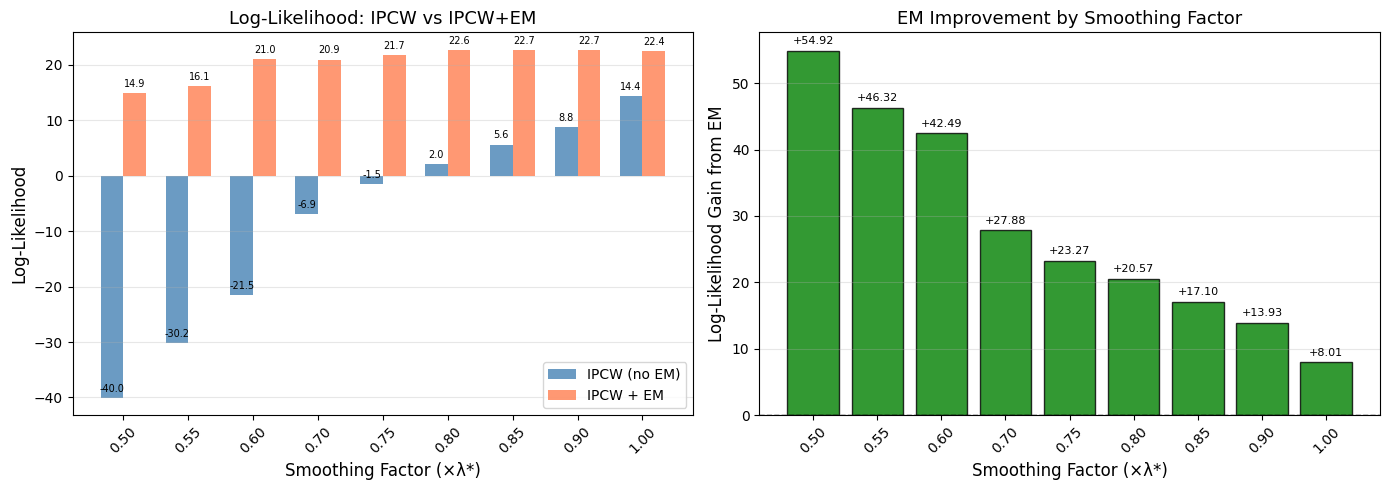

In [19]:
# Log-Likelihood Comparison Plot
# Use em_results_df directly for adaptive sizing (not em_factors_to_test which may differ)
n_results = len(em_results_df)
factors_tested = em_results_df['factor'].values

# Adjust figure width based on number of results
fig_width = max(14, n_results * 1.5)
fig, axes = plt.subplots(1, 2, figsize=(fig_width, 5))

# Plot 1: Log-likelihood comparison (IPCW vs IPCW+EM)
ax1 = axes[0]
x = np.arange(n_results)
width = 0.35

bars1 = ax1.bar(x - width/2, em_results_df['ipcw_ll'], width, label='IPCW (no EM)', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, em_results_df['em_ll'], width, label='IPCW + EM', color='coral', alpha=0.8)

ax1.set_xlabel('Smoothing Factor (×λ*)', fontsize=12)
ax1.set_ylabel('Log-Likelihood', fontsize=12)
ax1.set_title('Log-Likelihood: IPCW vs IPCW+EM', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{f:.2f}' for f in factors_tested], rotation=45 if n_results > 6 else 0)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3, axis='y')

# Add value labels on bars (skip if too many bars)
if n_results <= 10:
    for bar in bars1:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)
    for bar in bars2:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=7)

# Plot 2: LL Gain from EM
ax2 = axes[1]
colors = ['green' if g > 0 else 'red' for g in em_results_df['ll_gain']]
bars = ax2.bar(x, em_results_df['ll_gain'], color=colors, alpha=0.8, edgecolor='black')

ax2.set_xlabel('Smoothing Factor (×λ*)', fontsize=12)
ax2.set_ylabel('Log-Likelihood Gain from EM', fontsize=12)
ax2.set_title('EM Improvement by Smoothing Factor', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{f:.2f}' for f in factors_tested], rotation=45 if n_results > 6 else 0)
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.grid(alpha=0.3, axis='y')

# Add value labels
if n_results <= 10:
    for bar, gain in zip(bars, em_results_df['ll_gain']):
        height = bar.get_height()
        ax2.annotate(f'{gain:+.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                    ha='center', va='bottom' if height >= 0 else 'top', fontsize=8)

plt.tight_layout()
plt.show()

### 6.3 Density Estimates: Before vs After EM

Compare the density estimates before and after EM refinement.

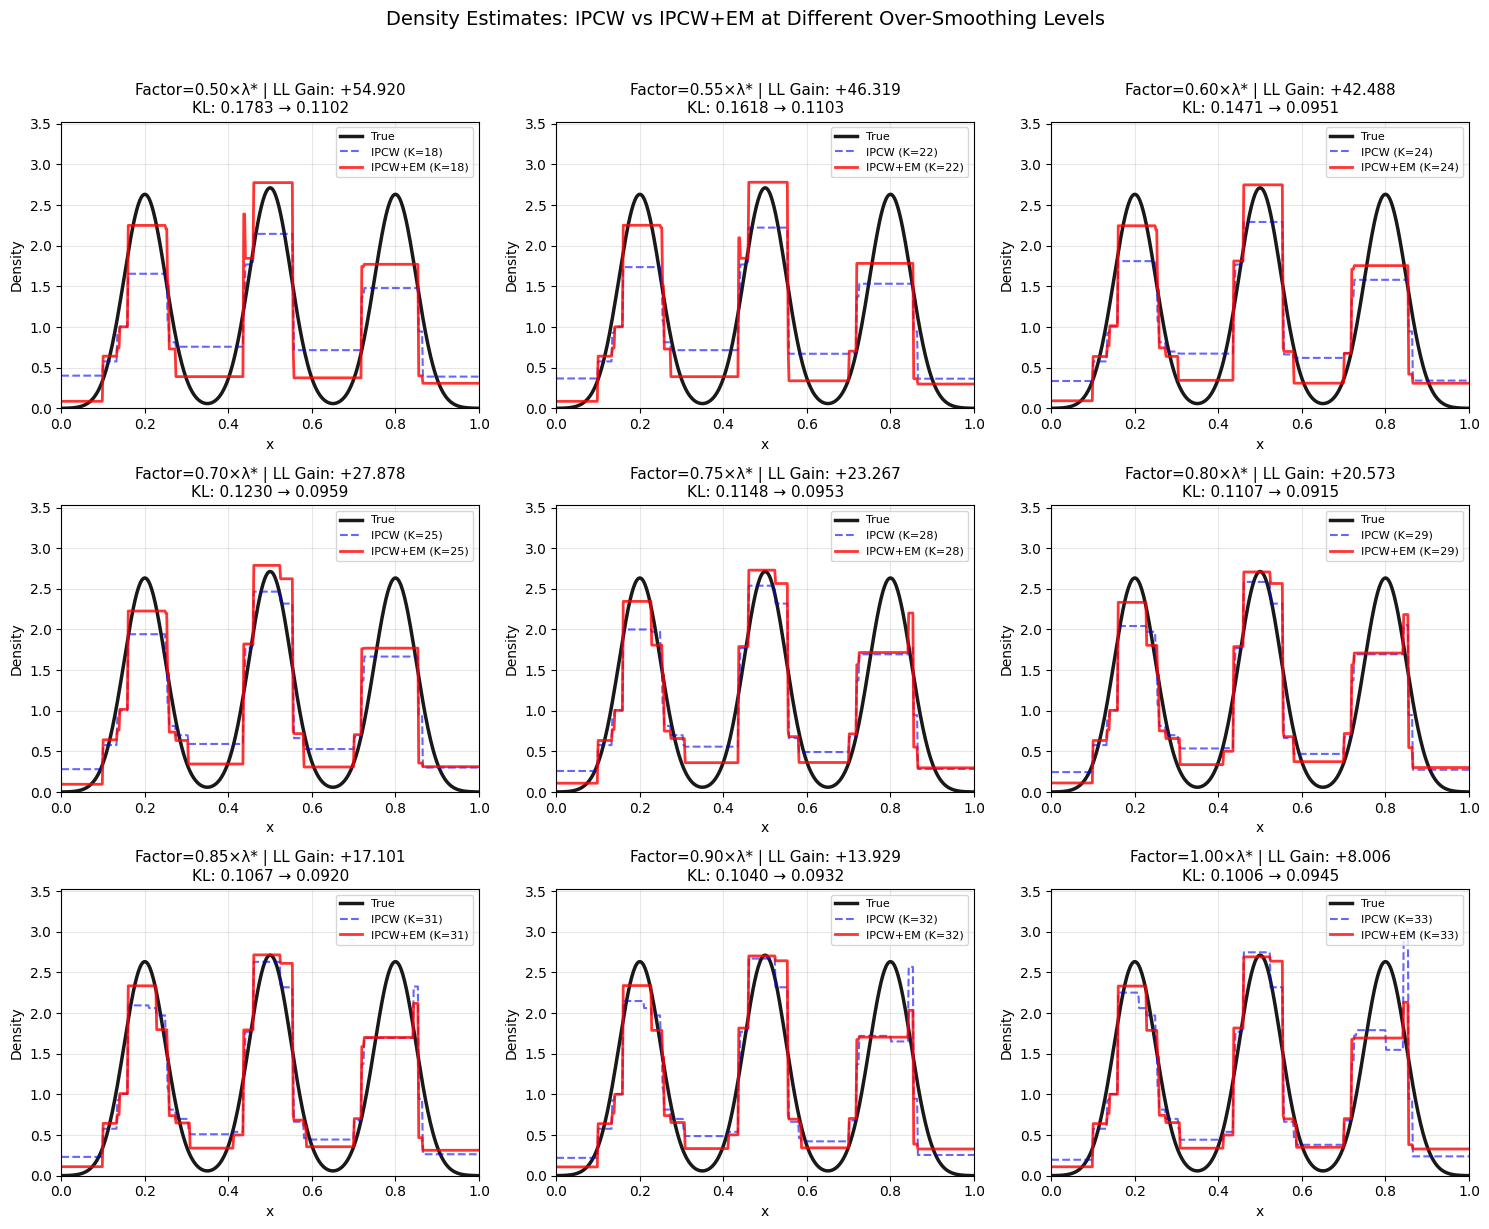

In [20]:
# Density comparison: Before vs After EM
# Make the grid adaptive based on number of results
n_results = len(em_results_df)
n_cols = min(3, n_results)  # Max 3 columns
n_rows = (n_results + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))

# Handle single plot case and flatten
if n_results == 1:
    axes = np.array([axes])
else:
    axes = np.atleast_1d(axes).flatten()

for idx, (_, row) in enumerate(em_results_df.iterrows()):
    if idx >= len(axes):
        break  # Safety check
    ax = axes[idx]
    factor = row['factor']
    
    # Get IPCW density from original results
    ipcw_row = results_df[results_df['factor'] == factor].iloc[0]
    ipcw_density = ipcw_row['density']
    
    # True density
    ax.plot(eval_grid, true_density, 'k-', linewidth=2.5, label='True', alpha=0.9)
    
    # IPCW density (before EM)
    ax.plot(eval_grid, ipcw_density, 'b--', linewidth=1.5, 
            label=f'IPCW (K={row["ipcw_knots"]})', alpha=0.6)
    
    # EM density (after EM)
    ax.plot(eval_grid, row['em_density'], 'r-', linewidth=2, 
            label=f'IPCW+EM (K={row["em_knots"]})', alpha=0.8)
    
    ax.set_xlabel('x', fontsize=10)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'Factor={factor:.2f}×λ* | LL Gain: {row["ll_gain"]:+.3f}\n'
                f'KL: {row["ipcw_kl"]:.4f} → {row["em_kl"]:.4f}', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, max(true_density) * 1.3)

# Hide any unused subplots
for idx in range(n_results, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Density Estimates: IPCW vs IPCW+EM at Different Over-Smoothing Levels', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Final Summary: Best Performing Methods

In [21]:
# Final Summary
print("="*80)
print("FINAL SUMMARY: OVER-SMOOTHING + EM REFINEMENT")
print("="*80)

# Find best methods
best_ipcw_idx = em_results_df['ipcw_ll'].idxmax()
best_ipcw = em_results_df.loc[best_ipcw_idx]

best_em_idx = em_results_df['em_ll'].idxmax()
best_em = em_results_df.loc[best_em_idx]

# Conservative baseline (factor=1.0)
baseline = em_results_df[em_results_df['factor'] == 1.0].iloc[0]

print(f"\n📊 BASELINE: Conservative CV IPCW (factor=1.0)")
print(f"   - Knots: {baseline['ipcw_knots']}")
print(f"   - Log-Likelihood: {baseline['ipcw_ll']:.4f}")
print(f"   - KL Divergence: {baseline['ipcw_kl']:.6f}")

print(f"\n📈 BASELINE + EM: Conservative CV IPCW + EM (factor=1.0)")
print(f"   - Knots: {baseline['ipcw_knots']} → {baseline['em_knots']}")
print(f"   - Log-Likelihood: {baseline['ipcw_ll']:.4f} → {baseline['em_ll']:.4f} ({baseline['ll_gain']:+.4f})")
print(f"   - KL Divergence: {baseline['ipcw_kl']:.6f} → {baseline['em_kl']:.6f}")

print(f"\n🏆 BEST IPCW (no EM): factor={best_ipcw['factor']:.2f}")
print(f"   - Knots: {best_ipcw['ipcw_knots']}")
print(f"   - Log-Likelihood: {best_ipcw['ipcw_ll']:.4f}")
print(f"   - KL Divergence: {best_ipcw['ipcw_kl']:.6f}")

print(f"\n🏆 BEST IPCW+EM: factor={best_em['factor']:.2f}")
print(f"   - Initial Knots: {best_em['ipcw_knots']} → Final Knots: {best_em['em_knots']}")
print(f"   - Log-Likelihood: {best_em['em_ll']:.4f}")
print(f"   - KL Divergence: {best_em['em_kl']:.6f}")
print(f"   - EM Iterations: {best_em['em_iterations']}")

# Overall comparison
print(f"\n" + "="*80)
print("IMPROVEMENT SUMMARY")
print("="*80)
print(f"\n• Best IPCW+EM vs Baseline IPCW:")
print(f"  LL improvement: {best_em['em_ll'] - baseline['ipcw_ll']:+.4f}")
print(f"  KL improvement: {best_em['em_kl'] - baseline['ipcw_kl']:+.6f} (negative is better)")

print(f"\n• Best IPCW+EM vs Baseline IPCW+EM:")
print(f"  LL improvement: {best_em['em_ll'] - baseline['em_ll']:+.4f}")
print(f"  KL improvement: {best_em['em_kl'] - baseline['em_kl']:+.6f} (negative is better)")

print("="*80)

FINAL SUMMARY: OVER-SMOOTHING + EM REFINEMENT

📊 BASELINE: Conservative CV IPCW (factor=1.0)
   - Knots: 33
   - Log-Likelihood: 14.4053
   - KL Divergence: 0.100601

📈 BASELINE + EM: Conservative CV IPCW + EM (factor=1.0)
   - Knots: 33 → 33
   - Log-Likelihood: 14.4053 → 22.4114 (+8.0061)
   - KL Divergence: 0.100601 → 0.094459

🏆 BEST IPCW (no EM): factor=1.00
   - Knots: 33
   - Log-Likelihood: 14.4053
   - KL Divergence: 0.100601

🏆 BEST IPCW+EM: factor=0.85
   - Initial Knots: 31 → Final Knots: 31
   - Log-Likelihood: 22.7179
   - KL Divergence: 0.092027
   - EM Iterations: 4

IMPROVEMENT SUMMARY

• Best IPCW+EM vs Baseline IPCW:
  LL improvement: +8.3126
  KL improvement: -0.008575 (negative is better)

• Best IPCW+EM vs Baseline IPCW+EM:
  LL improvement: +0.3066
  KL improvement: -0.002433 (negative is better)


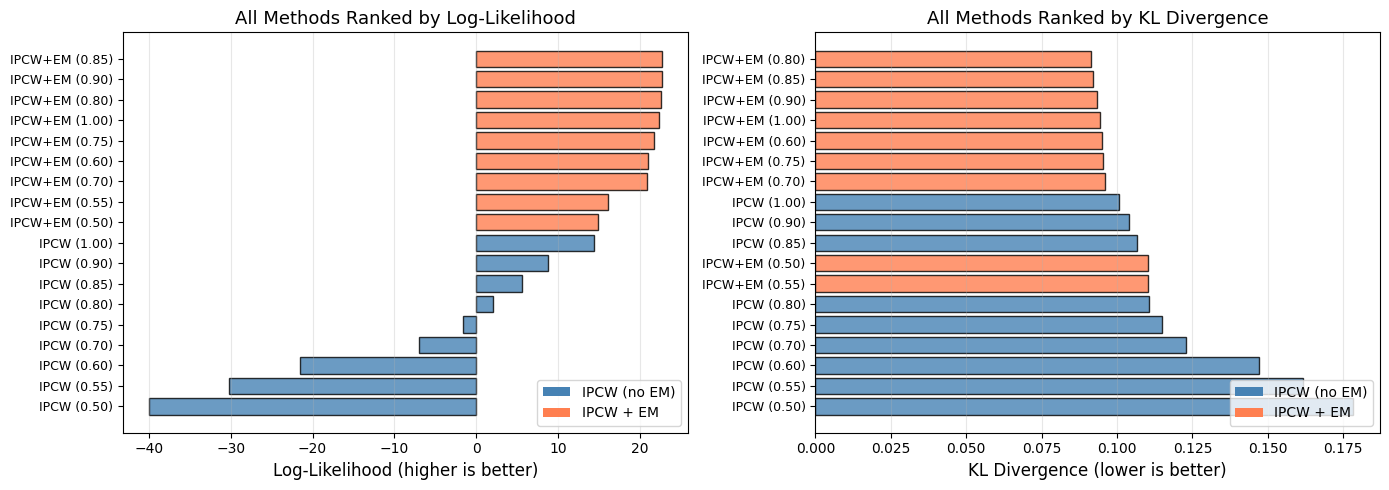

In [22]:
# All methods comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: All methods ranked by Log-Likelihood
ax1 = axes[0]

# Prepare data for ranking
all_methods = []
for _, row in em_results_df.iterrows():
    all_methods.append({
        'Method': f'IPCW ({row["factor"]:.2f})',
        'LL': row['ipcw_ll'],
        'KL': row['ipcw_kl'],
        'Type': 'IPCW'
    })
    all_methods.append({
        'Method': f'IPCW+EM ({row["factor"]:.2f})',
        'LL': row['em_ll'],
        'KL': row['em_kl'],
        'Type': 'IPCW+EM'
    })

all_methods_df = pd.DataFrame(all_methods).sort_values('LL', ascending=True)

colors = ['steelblue' if t == 'IPCW' else 'coral' for t in all_methods_df['Type']]
bars = ax1.barh(range(len(all_methods_df)), all_methods_df['LL'], color=colors, alpha=0.8, edgecolor='black')

ax1.set_yticks(range(len(all_methods_df)))
ax1.set_yticklabels(all_methods_df['Method'], fontsize=9)
ax1.set_xlabel('Log-Likelihood (higher is better)', fontsize=12)
ax1.set_title('All Methods Ranked by Log-Likelihood', fontsize=13)
ax1.grid(alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='IPCW (no EM)'),
                   Patch(facecolor='coral', label='IPCW + EM')]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Right: KL Divergence comparison
ax2 = axes[1]

all_methods_df_kl = all_methods_df.sort_values('KL', ascending=False)
colors_kl = ['steelblue' if t == 'IPCW' else 'coral' for t in all_methods_df_kl['Type']]
bars_kl = ax2.barh(range(len(all_methods_df_kl)), all_methods_df_kl['KL'], color=colors_kl, alpha=0.8, edgecolor='black')

ax2.set_yticks(range(len(all_methods_df_kl)))
ax2.set_yticklabels(all_methods_df_kl['Method'], fontsize=9)
ax2.set_xlabel('KL Divergence (lower is better)', fontsize=12)
ax2.set_title('All Methods Ranked by KL Divergence', fontsize=13)
ax2.grid(alpha=0.3, axis='x')
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Conclusions

### Key Findings

1. **EM consistently improves Log-Likelihood**: Across all smoothing factors, EM refinement increases the observed log-likelihood compared to IPCW alone.

2. **Over-smoothing + EM is effective**: Starting with a simpler (over-smoothed) initial model and applying EM can achieve results comparable to or better than starting with the CV-optimal model.

3. **Trade-off considerations**:
   - **Model complexity**: Over-smoothed models start with fewer knots
   - **EM refinement**: Allows the model to adapt and capture more complexity
   - **Robustness**: Simpler initial models may be more robust to noise

### Recommended Workflow

```
1. Use conservative CV to find optimal λ*
2. Choose over-smoothing factor (0.6-0.8 recommended)
3. Fit initial IPCW with factor × λ*
4. Apply EM with M-step constraint = 1 × λ*
5. Evaluate using incomplete log-likelihood
```

### Summary Table

| Method | Best Factor | Pros | Cons |
|--------|-------------|------|------|
| IPCW only | 1.0 | Simple, fast | May overfit |
| Over-smoothed IPCW | 0.5-0.7 | Robust, fewer knots | May underfit |
| IPCW + EM | 1.0 | Best fit | More computation |
| Over-smoothed IPCW + EM | 0.6-0.8 | Good balance | Moderate computation |